### Spearman Rank Correlation and Kendall Tau Correlation
### Quick Overview
- **Rank-Based Metrics:** Unlike Pearson correlation (which evaluates linear relationships between raw values), Spearman's $\rho$ and Kendall's $\tau$ evaluate monotonic relationships using ranks.
- **Robust to Outliers:** Because values are converted to ordinal ranks, extreme outliers do not disproportionately distort the relationship.
- **Spearman vs. Kendall:** Spearman's $\rho$ measures the variance of rank differences (similar to Pearson on ranks), whereas Kendall's $\tau$ measures relative pairwise order concordances, making Kendall better suited for **small samples** or datasets with tied ranks.

- Spearman $\rho$ (Difference-Based)
- Kendall's $\tau$ (pairwise agreement - based)

### Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Apply clean visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 100

## 1. Spearman Rank Correlation Coefficient ($\rho$)

* **What it does:** Measures the strength and direction of a monotonic relationship between two variables by converting raw values into ranks before assessing correlation.
* **Mathematical Notation:**
  $$r_s = \rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
  *Where:*
  * $r_s$ (*r sub s*) or $\rho$ (*rho*): Spearman rank correlation coefficient
  * $d_i$ (*d sub i*): Difference between the ranks of corresponding values ($R(x_i) - R(y_i)$)
  * $n$ (*n*): Total number of observations
* **Naive Example:** 3 students evaluated on Aptitude $X = [10, 50, 30]$ and Coding Score $Y = [20, 80, 40]$ ($n = 3$).
  * Ranks $X$: $[1, 3, 2]$, Ranks $Y$: $[1, 3, 2]$
  * Differences $d_i$: $[0, 0, 0]$, $\sum d_i^2 = 0$
  * Spearman Correlation: $r_s = 1 - \frac{6(0)}{3(9 - 1)} = 1.0$ (Perfect Monotonic Correlation)
* **When to use:** When data is ordinal, non-linearly monotonic, or contains extreme values that would skew Pearson's correlation coefficient.

---

### Spearman Rank Correlation: Step-by-Step Numerical Example

Spearman's rank correlation replaces raw data points with their relative ranks (1 = smallest, $n$ = largest) and computes correlation based on rank differences.

---

### Step-by-Step Example

#### 1. Input Datasets
$$\text{Customer Tenure in Months } (X): [5, 50, 12, 100] \quad (n = 4)$$
$$\text{Total Spend in USD } (Y): [100, 5000, 250, 15000] \quad (n = 4)$$

#### 2. Assign Ranks to $X$ and $Y$
* Ranks for $X$: $5 \rightarrow 1$, $12 \rightarrow 2$, $50 \rightarrow 3$, $100 \rightarrow 4$
* Ranks for $Y$: $100 \rightarrow 1$, $250 \rightarrow 2$, $5000 \rightarrow 3$, $15000 \rightarrow 4$

#### 3. Compute Rank Differences ($d_i$) and Squared Differences ($d_i^2$)
| Customer | $X_i$ | $Y_i$ | Rank($X_i$) | Rank($Y_i$) | $d_i = R(X_i) - R(Y_i)$ | $d_i^2$ |
|---|---|---|---|---|---|---|
| 1 | 5 | 100 | 1 | 1 | $1 - 1 = 0$ | $0$ |
| 2 | 50 | 5000 | 3 | 3 | $3 - 3 = 0$ | $0$ |
| 3 | 12 | 250 | 2 | 2 | $2 - 2 = 0$ | $0$ |
| 4 | 100 | 15000 | 4 | 4 | $4 - 4 = 0$ | $0$ |

#### 4. Calculate Sum of Squared Differences
$$\sum d_i^2 = 0 + 0 + 0 + 0 = 0$$

#### 5. Calculate Spearman Rank Correlation
$$r_s = 1 - \frac{6 \times 0}{4(4^2 - 1)} = 1 - 0 = 1.0$$

Plain Python Spearman r: 1.0000
Scipy Spearman r:        1.0000
Pandas Spearman r:       1.0000


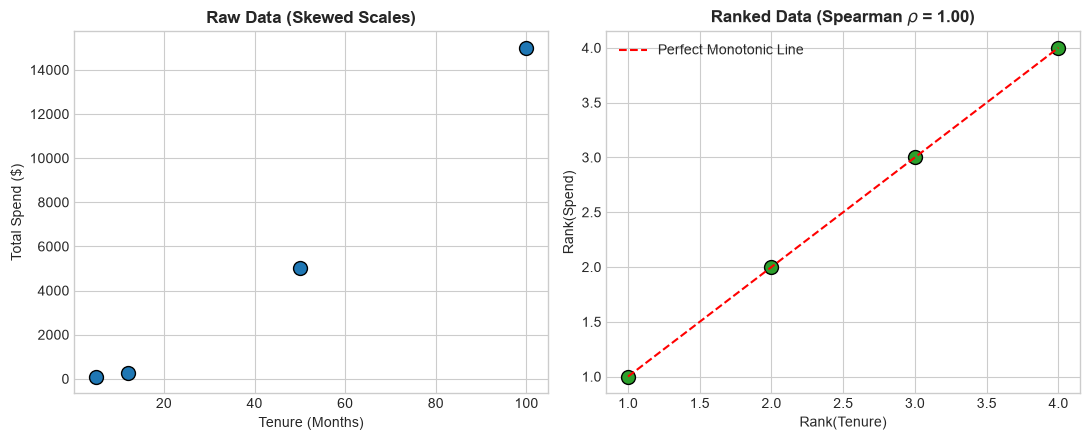

In [ ]:
# --- 1. DATA PREPARATION ---
x_tenure = np.array([5, 50, 12, 100])
y_spend = np.array([100, 5000, 250, 15000])
n = len(x_tenure)
# --- 2. PLAIN PYTHON IMPLEMENTATION ---
# Compute ordinal ranks manually
rank_x = pd.Series(x_tenure).rank().values
rank_y = pd.Series(y_spend).rank().values

d = rank_x - rank_y
sum_d2 = sum(d ** 2)
spearman_python = 1 - (6 * sum_d2) / (n * (n**2 - 1))
# --- 3. SCIPY & PANDAS IMPLEMENTATIONS ---
spearman_scipy, p_val = stats.spearmanr(x_tenure, y_spend)
spearman_pandas = pd.Series(x_tenure).corr(pd.Series(y_spend), method='spearman')
print(f"Plain Python Spearman r: {spearman_python:.4f}")
print(f"Scipy Spearman r:        {spearman_scipy:.4f}")
print(f"Pandas Spearman r:       {spearman_pandas:.4f}")


# --- 4. VISUAL REPRESENTATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Raw Values Scatter Plot
ax1.scatter(x_tenure, y_spend, color='#1f77b4', s=100, edgecolors='k')
ax1.set_title('Raw Data (Skewed Scales)', fontweight='bold')
ax1.set_xlabel('Tenure (Months)')
ax1.set_ylabel('Total Spend ($)')

# Ranked Values Scatter Plot
ax2.scatter(rank_x, rank_y, color='#2ca02c', s=100, edgecolors='k')
ax2.plot([1, 4], [1, 4], color='red', linestyle='--', label='Perfect Monotonic Line')
ax2.set_title(f'Ranked Data (Spearman $\\rho$ = {spearman_scipy:.2f})', fontweight='bold')
ax2.set_xlabel('Rank(Tenure)')
ax2.set_ylabel('Rank(Spend)')
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Kendall Tau Correlation Coefficient ($\tau$)
* **What it does:** Measures ordinal association by counting concordant and discordant pairs among all combinations of observations.

* **Mathematical Notation:**
  $$\tau = \frac{C - D}{\frac{1}{2} n (n - 1)}$$
  *Where:*
  * $\tau$ (*tau*): Kendall tau rank correlation coefficient
  * $C$ (*C*): Number of concordant pairs (where ordering matches: $x_i > x_j$ and $y_i > y_j$)
  * $D$ (*D*): Number of discordant pairs (where ordering differs: $x_i > x_j$ but $y_i < y_j$)
  * $\frac{1}{2} n (n - 1)$: Total number of unique pairs among $n$ observations
* **Naive Example:** 3 candidates ranked by Interviewer A $X = [1, 2, 3]$ and Interviewer B $Y = [1, 3, 2]$ ($n = 3$, Total pairs = 3).
  * Pair (1,2): A gives $1 < 2$, B gives $1 < 3 \implies$ Concordant
  * Pair (1,3): A gives $1 < 3$, B gives $1 < 2 \implies$ Concordant
  * Pair (2,3): A gives $2 < 3$, B gives $3 > 2 \implies$ Discordant
  * $C = 2, D = 1 \implies \tau = \frac{2 - 1}{3} = 0.3333$
* **When to use:** When dealing with small sample sizes, heavy tied ranks, or when strict statistical significance tests on pairwise ordering are required.

### Kendall Tau Correlation: Step-by-Step Numerical Example

Kendall's $\tau$ checks every unique pair of data points to see if their relative directions agree (concordant) or disagree (discordant).

---

### Step-by-Step Example

#### 1. Input Datasets
$$\text{Product Quality Rank } (X): [1, 2, 3, 4] \quad (n = 4)$$
$$\text{Customer Satisfaction Rank } (Y): [1, 3, 2, 4] \quad (n = 4)$$

#### 2. Identify All Unique Pairs
Total unique pairs: $\frac{n(n - 1)}{2} = \frac{4 \times 3}{2} = 6$ pairs.

#### 3. Evaluate Concordance and Discordance for Each Pair
| Pair $(i, j)$ | Values $X$ | Values $Y$ | $X$ Direction | $Y$ Direction | Result |
|---|---|---|---|---|---|
| (1, 2) | $1 < 2$ | $1 < 3$ | Increasing | Increasing | **Concordant** ($C$) |
| (1, 3) | $1 < 3$ | $1 < 2$ | Increasing | Increasing | **Concordant** ($C$) |
| (1, 4) | $1 < 4$ | $1 < 4$ | Increasing | Increasing | **Concordant** ($C$) |
| (2, 3) | $2 < 3$ | $3 > 2$ | Increasing | Decreasing | **Discordant** ($D$) |
| (2, 4) | $2 < 4$ | $3 < 4$ | Increasing | Increasing | **Concordant** ($C$) |
| (3, 4) | $3 < 4$ | $2 < 4$ | Increasing | Increasing | **Concordant** ($C$) |

#### 4. Total Counts
* Concordant pairs ($C$) = $5$
* Discordant pairs ($D$) = $1$

#### 5. Calculate Kendall Tau Coefficient
$$\tau = \frac{C - D}{\text{Total Pairs}} = \frac{5 - 1}{6} = \frac{4}{6} = 0.6667$$

Plain Python Kendall Tau: 0.6667
SciPy stats.kendalltau:  0.6667 (p-value: 0.3333)
Pandas Series corr:       0.6667



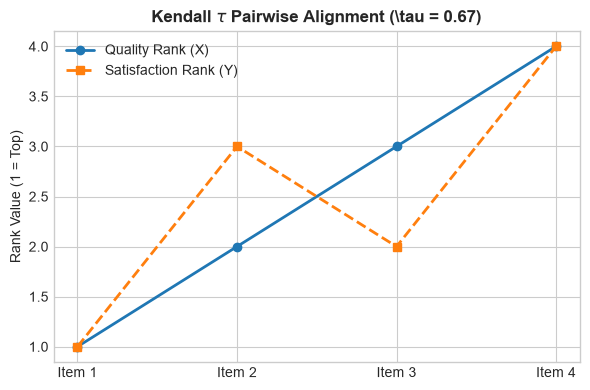

In [6]:
# --- 1. DATA PREPARATION ---
x_rank = np.array([1, 2, 3, 4])
y_rank = np.array([1, 3, 2, 4])
n = len(x_rank)

# --- 2. PLAIN PYTHON IMPLEMENTATION ---
concordant = 0
discordant = 0

for i in range(n):
    for j in range(i + 1, n):
        dx = x_rank[i] - x_rank[j]
        dy = y_rank[i] - y_rank[j]
        prod = dx * dy
        if prod > 0:
            concordant += 1
        elif prod < 0:
            discordant += 1

total_pairs = (n * (n - 1)) // 2
kendall_python = (concordant - discordant) / total_pairs


# --- 3. SCIPY & PANDAS IMPLEMENTATIONS ---
kendall_scipy, p_val_k = stats.kendalltau(x_rank, y_rank)
kendall_pandas = pd.Series(x_rank).corr(pd.Series(y_rank), method='kendall')

print(f"Plain Python Kendall Tau: {kendall_python:.4f}")
print(f"SciPy stats.kendalltau:  {kendall_scipy:.4f} (p-value: {p_val_k:.4f})")
print(f"Pandas Series corr:       {kendall_pandas:.4f}\n")

# --- 4. VISUAL REPRESENTATION ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, n+1), x_rank, marker='o', label='Quality Rank (X)', linewidth=2, color='#1f77b4')
ax.plot(range(1, n+1), y_rank, marker='s', label='Satisfaction Rank (Y)', linewidth=2, linestyle='--', color='#ff7f0e')

ax.set_xticks(range(1, n+1))
ax.set_xticklabels([f'Item {i}' for i in range(1, n+1)])
ax.set_ylabel('Rank Value (1 = Top)')
ax.set_title(f'Kendall $\\tau$ Pairwise Alignment (\\tau = {kendall_scipy:.2f})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

#### 3. Pearson vs. Spearman vs. Kendall: Outlier Robustness

* **What it does:** Demonstrates how a single extreme outlier severely skews Pearson correlation while leaving rank-based correlations (Spearman and Kendall) virtually untouched.
* **Mathematical Notation:**
  $$\text{Original Clean Data: } r_{\text{pearson}} \approx 0.99, \quad r_{\text{spearman}} = 1.0, \quad \tau_{\text{kendall}} = 1.0$$
  $$\text{Corrupted Outlier Data: } r_{\text{pearson}} \ll 0, \quad r_{\text{spearman}} \approx 0.90, \quad \tau_{\text{kendall}} \approx 0.80$$
* **Naive Example:** Clean sequence $X = [1, 2, 3, 4, 5]$ and $Y = [10, 20, 30, 40, 50]$. Introducing an outlier at the last point $Y[4] = -500$.
  * Pearson drops drastically because it computes Euclidean distances from means.
  * Spearman and Kendall only reassign rank $1$ to $-500$, preserving the relative ordering of the remaining 4 items.
* **When to use:** Crucial when evaluating financial data, sensor metrics, or survey inputs where bad telemetry/outliers are common.

=== CLEAN DATA metrics ===
Pearson r:  0.9989 | Spearman r_s: 1.0000 | Kendall tau: 1.0000

=== OUTLIER CORRUPTED DATA metrics ===
Pearson r:  -0.3900 (Severely flipped negative!)
Spearman r_s: 0.4545 (Remains robust)
Kendall tau:  0.6000 (Remains robust)



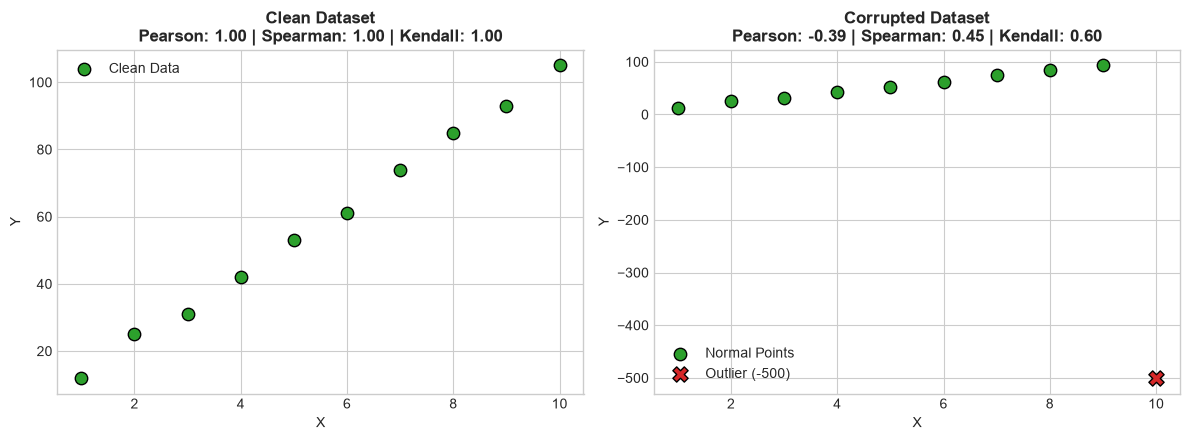

In [7]:
# --- 1. DATASET GENERATION WITH OUTLIER ---
x_clean = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_clean = np.array([12, 25, 31, 42, 53, 61, 74, 85, 93, 105])

# Inject a severe measurement error outlier
x_outlier = x_clean.copy()
y_outlier = y_clean.copy()
y_outlier[-1] = -500  # Extreme anomaly

# Compute correlations for Clean Data
p_clean = np.corrcoef(x_clean, y_clean)[0, 1]
s_clean, _ = stats.spearmanr(x_clean, y_clean)
k_clean, _ = stats.kendalltau(x_clean, y_clean)

# Compute correlations for Outlier Data
p_outlier = np.corrcoef(x_outlier, y_outlier)[0, 1]
s_outlier, _ = stats.spearmanr(x_outlier, y_outlier)
k_outlier, _ = stats.kendalltau(x_outlier, y_outlier)

print("=== CLEAN DATA metrics ===")
print(f"Pearson r:  {p_clean:.4f} | Spearman r_s: {s_clean:.4f} | Kendall tau: {k_clean:.4f}")
print("\n=== OUTLIER CORRUPTED DATA metrics ===")
print(f"Pearson r:  {p_outlier:.4f} (Severely flipped negative!)")
print(f"Spearman r_s: {s_outlier:.4f} (Remains robust)")
print(f"Kendall tau:  {k_outlier:.4f} (Remains robust)\n")

# --- 2. MULTI-PANEL VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot Clean Data
ax1.scatter(x_clean, y_clean, color='#2ca02c', s=80, edgecolors='k', label='Clean Data')
ax1.set_title(f'Clean Dataset\nPearson: {p_clean:.2f} | Spearman: {s_clean:.2f} | Kendall: {k_clean:.2f}', fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.legend()

# Plot Outlier Data
ax2.scatter(x_outlier[:-1], y_outlier[:-1], color='#2ca02c', s=80, edgecolors='k', label='Normal Points')
ax2.scatter(x_outlier[-1], y_outlier[-1], color='#d62728', s=120, edgecolors='k', marker='X', label='Outlier (-500)')
ax2.set_title(f'Corrupted Dataset\nPearson: {p_outlier:.2f} | Spearman: {s_outlier:.2f} | Kendall: {k_outlier:.2f}', fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()

plt.tight_layout()
plt.show()